In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv(r'C:\Users\admin\OneDrive\Desktop\data science projects\exploratory health care\archive (1)\healthcare-dataset-stroke-data.csv')
print(df.shape)      # Print number of rows and columns
df.head(5)           # Preview the first few rows


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [ ]:
df['smoking_status'].replace('Unknown', np.nan, inplace=True)
df.isnull().sum()


C:\Users\admin\AppData\Local\Temp\ipykernel_9936\4231687938.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoking_status'].replace('Unknown', np.nan, inplace=True)


id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

In [ ]:
df_clean = df.dropna(subset=['bmi', 'smoking_status'])
print(df_clean.shape)


(3426, 12)


In [ ]:
df_clean.drop_duplicates(inplace=True)


C:\Users\admin\AppData\Local\Temp\ipykernel_9936\291987672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop_duplicates(inplace=True)


In [ ]:
df_clean[['age','avg_glucose_level','bmi']].describe()


,age,avg_glucose_level,bmi
count,3426.000000,3426.000000,3426.000000
mean,48.645943,108.321891,30.290047
std,18.851239,47.703541,7.295958
min,10.000000,55.120000,11.500000
25%,34.000000,77.237500,25.300000
50%,50.000000,92.360000,29.100000
75%,63.000000,116.207500,34.100000
max,82.000000,271.740000,92.000000


In [ ]:
df_clean.describe(include=['object'])


,gender,ever_married,work_type,Residence_type,smoking_status
count,3426,3426,3426,3426,3426
unique,3,2,5,2,3
top,Female,Yes,Private,Urban,never smoked
freq,2086,2599,2201,1745,1852


Text(0, 0.5, 'Count')

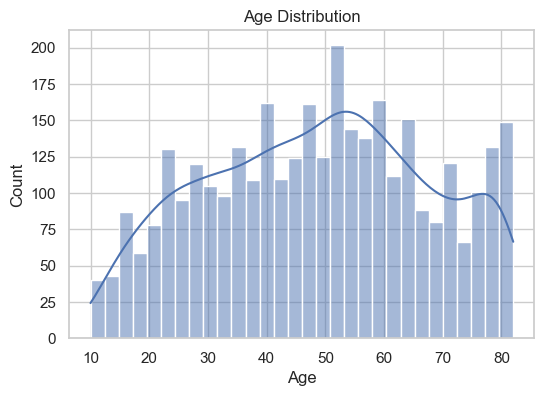

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age'); plt.ylabel('Count')


Text(0.5, 0, 'Glucose')

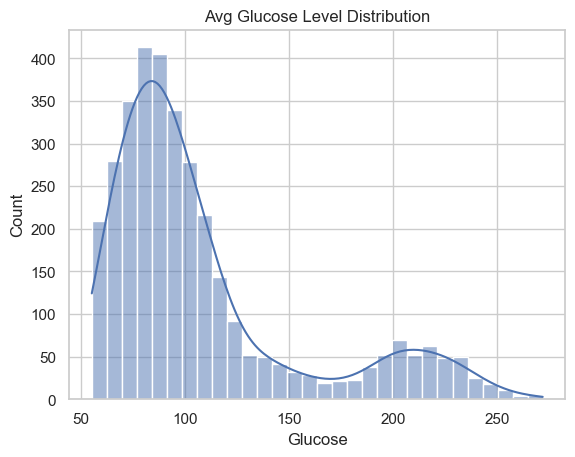

In [ ]:
sns.histplot(df_clean['avg_glucose_level'], bins=30, kde=True)
plt.title('Avg Glucose Level Distribution')
plt.xlabel('Glucose')


Text(0.5, 0, 'BMI')

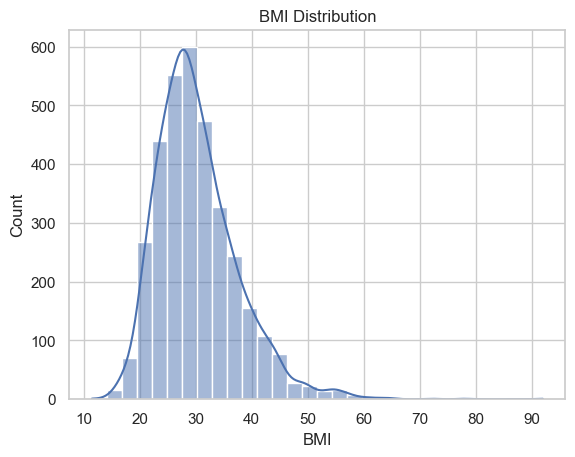

In [ ]:
sns.histplot(df_clean['bmi'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')


Text(0.5, 1.0, 'Age Boxplot')

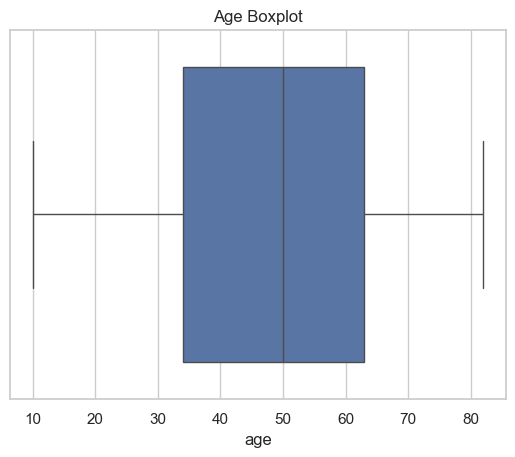

In [ ]:
sns.boxplot(x=df_clean['age'])
plt.title('Age Boxplot')


Text(0.5, 1.0, 'Gender Count')

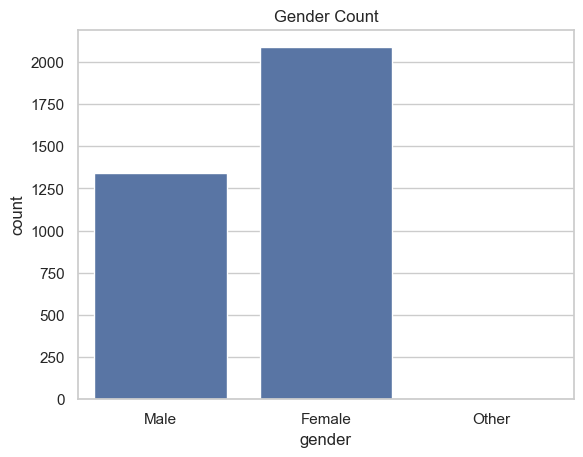

In [ ]:
sns.countplot(x='gender', data=df_clean)
plt.title('Gender Count')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Private'),
  Text(1, 0, 'Self-employed'),
  Text(2, 0, 'Govt_job'),
  Text(3, 0, 'children'),
  Text(4, 0, 'Never_worked')])

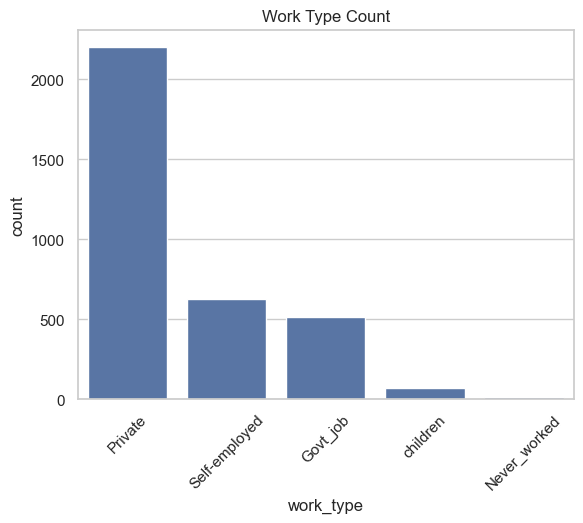

In [ ]:
sns.countplot(x='work_type', data=df_clean)
plt.title('Work Type Count')
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Hypertension (0=No, 1=Yes)')

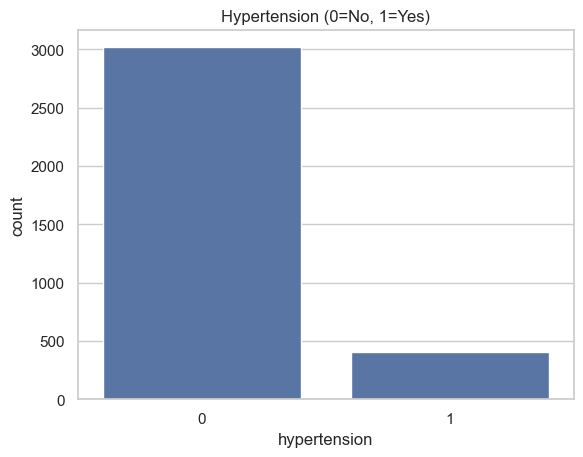

In [ ]:
sns.countplot(x='hypertension', data=df_clean)
plt.title('Hypertension (0=No, 1=Yes)')


([<matplotlib.axis.XTick at 0x1b7026c9a90>,
 [Text(0, 0, 'No Stroke'), Text(1, 0, 'Stroke')])

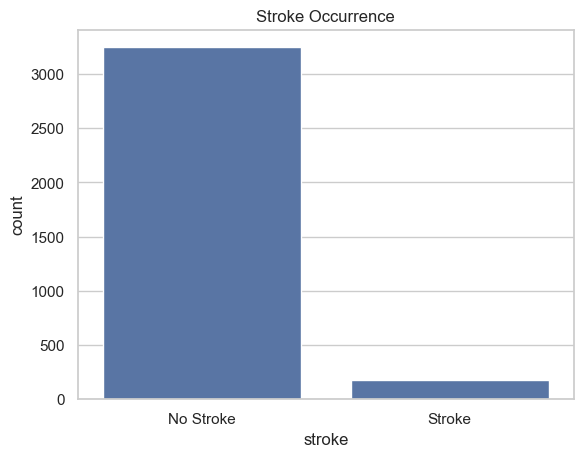

In [ ]:
sns.countplot(x='stroke', data=df_clean)
plt.title('Stroke Occurrence')
plt.xticks([0,1], ['No Stroke','Stroke'])


Text(0.5, 1.0, 'Age vs Avg Glucose (colored by Stroke)')

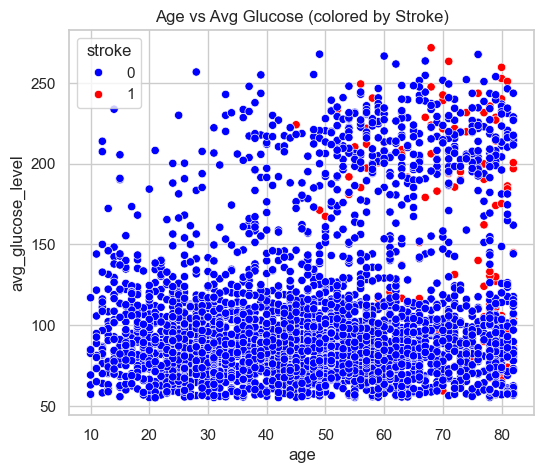

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke', data=df_clean, palette={0:'blue',1:'red'})
plt.title('Age vs Avg Glucose (colored by Stroke)')


([<matplotlib.axis.XTick at 0x1b702ac4cd0>,
 [Text(0, 0, 'No Stroke'), Text(1, 0, 'Stroke')])

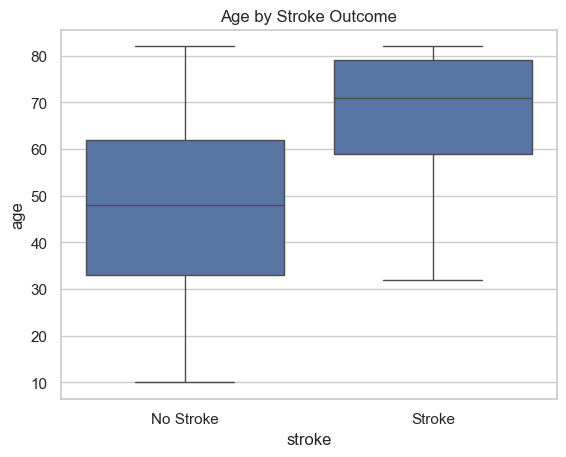

In [ ]:
sns.boxplot(x='stroke', y='age', data=df_clean)
plt.title('Age by Stroke Outcome')
plt.xticks([0,1], ['No Stroke','Stroke'])


([<matplotlib.axis.XTick at 0x1b702b2e210>,
 [Text(0, 0, 'No Stroke'), Text(1, 0, 'Stroke')])

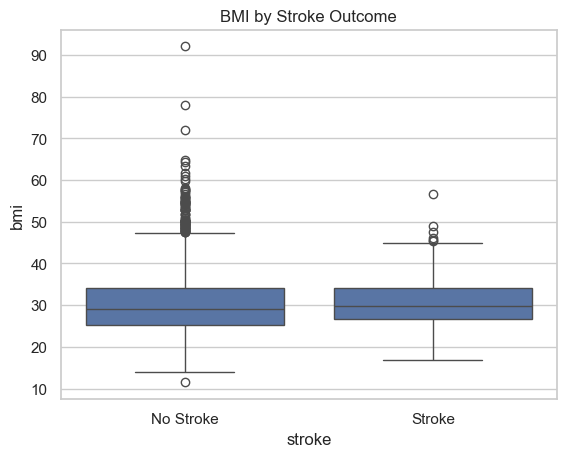

In [ ]:
sns.boxplot(x='stroke', y='bmi', data=df_clean)
plt.title('BMI by Stroke Outcome')
plt.xticks([0,1], ['No Stroke','Stroke'])


In [ ]:
pd.crosstab(df_clean['gender'], df_clean['stroke'])


stroke,0,1
gender,,
Female,1981,105
Male,1264,75
Other,1,0


Text(0.5, 1.0, 'Stroke by Gender')

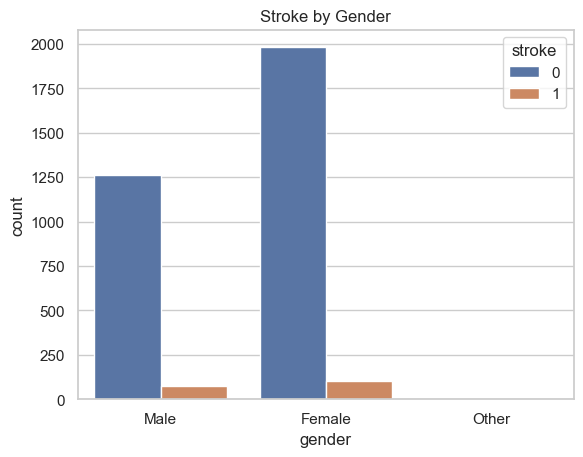

In [ ]:
sns.countplot(x='gender', hue='stroke', data=df_clean)
plt.title('Stroke by Gender')


Text(0.5, 1.0, 'Correlation Matrix')

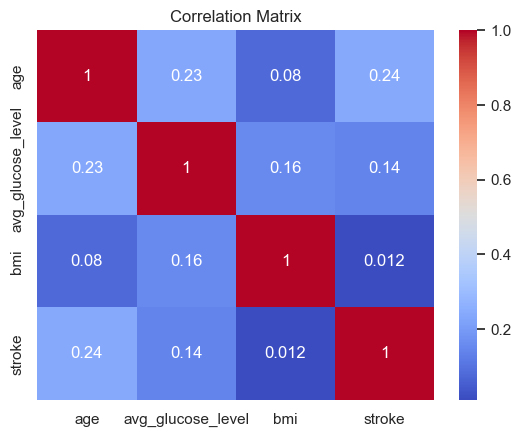

In [ ]:
corr = df_clean[['age','avg_glucose_level','bmi','stroke']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
